# Part 1 — FRE as an RL Reward Signal (REINFORCE)

**Goal:** Fine-tune `Qwen/Qwen2.5-1.5B-Instruct` using REINFORCE where the reward is derived from the Flesch Reading Ease (FRE) score of generated biomedical explanations.

**Pipeline:**
1. Load model and a small set of biomedical explanation prompts
2. Define a shaped FRE reward per user category (BEGINNER / EXPERT)
3. Run REINFORCE training for a small number of steps
4. Evaluate and compare FRE scores before vs after training
5. Analyse results and identify the reward-hacking failure mode → motivates Part 2

---
> **Note:** This notebook is designed to run on a single GPU (or CPU for small steps). All samples are minimal to demonstrate the method clearly.

## 1. Setup and Imports

In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import textstat
import warnings
import copy
from transformers import AutoTokenizer, AutoModelForCausalLM

warnings.filterwarnings('ignore')
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

c:\Users\vimal\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


## 2. Load Qwen2.5-1.5B-Instruct

In [2]:
MODEL_ID = 'Qwen/Qwen2.5-1.5B-Instruct'

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token

# Load base model (we'll keep a frozen reference copy for before/after comparison)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float32,
    trust_remote_code=True,
).to(device)

# Frozen reference copy — used to generate 'before' outputs at evaluation
ref_model = copy.deepcopy(model).eval()
for p in ref_model.parameters():
    p.requires_grad_(False)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-6)

print(f'Model loaded: {sum(p.numel() for p in model.parameters())/1e6:.1f}M parameters')

Sliding Window Attention is enabled but not implemented for `sdpa`; unexpected results may be encountered.


Model loaded: 1543.7M parameters


## 3. Biomedical Explanation Prompts

In [3]:
# Small representative set covering BEGINNER and EXPERT categories
# Mirrors the ontology-enriched format from the XAI pipeline
SAMPLES = [
    {
        'predicted_class': 'Cardiovascular diseases',
        'user_category': 'BEGINNER',
        'feature_word': 'hypertension',
        'ancestors': 'disease -> disease of anatomical entity -> cardiovascular system disease',
    },
    {
        'predicted_class': 'Cardiovascular diseases',
        'user_category': 'EXPERT',
        'feature_word': 'hypertension',
        'ancestors': 'disease -> disease of anatomical entity -> cardiovascular system disease',
    },
    {
        'predicted_class': 'Nervous system diseases',
        'user_category': 'BEGINNER',
        'feature_word': 'neuropathy',
        'ancestors': 'disease -> nervous system disease -> peripheral neuropathy',
    },
    {
        'predicted_class': 'Nervous system diseases',
        'user_category': 'EXPERT',
        'feature_word': 'neuropathy',
        'ancestors': 'disease -> nervous system disease -> peripheral neuropathy',
    },
    {
        'predicted_class': 'Neoplasms',
        'user_category': 'BEGINNER',
        'feature_word': 'carcinoma',
        'ancestors': 'disease -> neoplasm -> malignant neoplasm -> carcinoma',
    },
    {
        'predicted_class': 'Neoplasms',
        'user_category': 'EXPERT',
        'feature_word': 'carcinoma',
        'ancestors': 'disease -> neoplasm -> malignant neoplasm -> carcinoma',
    },
]


def build_prompt(sample: dict) -> str:
    category = sample['user_category']
    style_instruction = (
        'Use plain, simple language suitable for a non-medical person.'
        if category == 'BEGINNER'
        else 'Use precise clinical and biomedical terminology appropriate for a medical expert.'
    )
    return (
        f'You are a biomedical explanation assistant.\n'
        f'The model predicted: {sample["predicted_class"]}\n'
        f'Key feature: {sample["feature_word"]} '
        f'(ontology path: {sample["ancestors"]})\n'
        f'User level: {category}. {style_instruction}\n'
        f'Write a 3-sentence explanation of why this prediction was made.\n\n'
        f'Explanation:'
    )

# Preview one prompt
print(build_prompt(SAMPLES[0]))

You are a biomedical explanation assistant.
The model predicted: Cardiovascular diseases
Key feature: hypertension (ontology path: disease -> disease of anatomical entity -> cardiovascular system disease)
User level: BEGINNER. Use plain, simple language suitable for a non-medical person.
Write a 3-sentence explanation of why this prediction was made.

Explanation:


## 4. FRE Reward Function

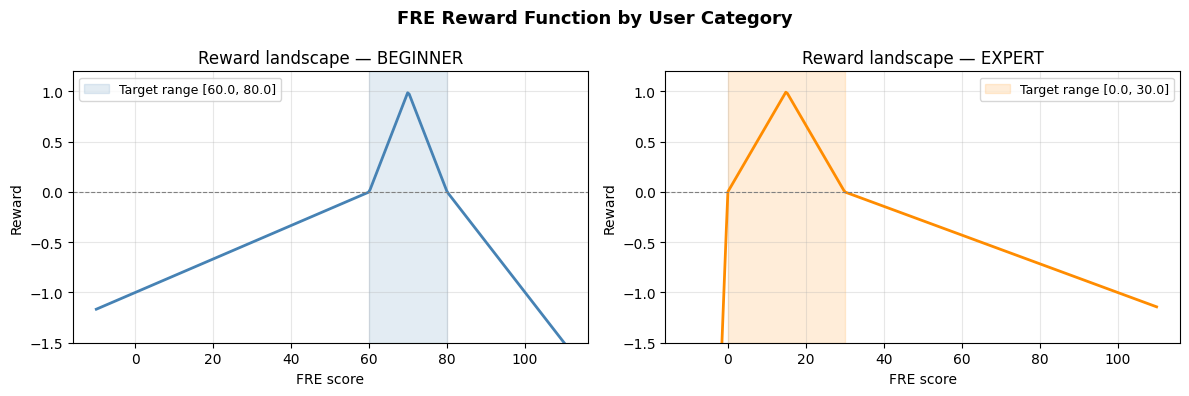

Reward landscape saved.


In [4]:
# Target FRE ranges per user category
FRE_TARGETS = {
    'BEGINNER':     (60.0, 80.0),
    'INTERMEDIATE': (30.0, 60.0),
    'EXPERT':       (0.0,  30.0),
}


def fre_reward(text: str, user_category: str) -> float:
    """
    Shaped reward based on how close the generated text's FRE is
    to the target range for the given user category.

    Returns a value in [-1, 1]:
      +1  = perfectly centred in target range
       0  = at the range boundary
      <0  = outside the target range (penalised)
    """
    fre = textstat.flesch_reading_ease(text)
    lo, hi = FRE_TARGETS[user_category]
    center = (lo + hi) / 2.0

    if lo <= fre <= hi:
        # Positive reward, scaled by proximity to centre
        reward = 1.0 - abs(fre - center) / ((hi - lo) / 2.0)
    elif fre < lo:
        # Too hard — penalise
        reward = (fre - lo) / max(lo, 1.0)
    else:
        # Too easy — penalise
        reward = (hi - fre) / max(100.0 - hi, 1.0)

    return float(reward)


# Visualise the reward landscape
fre_range = np.linspace(-10, 110, 300)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, cat, color in zip(axes, ['BEGINNER', 'EXPERT'], ['steelblue', 'darkorange']):
    rewards = [fre_reward_val := fre_reward.__wrapped__(fre_range[i], cat)
               if hasattr(fre_reward, '__wrapped__')
               else (_ := textstat.flesch_reading_ease, fre_reward(str(fre_range[i]), cat))[1]
               for i in range(len(fre_range))]
    # Direct computation for plot clarity
    lo, hi = FRE_TARGETS[cat]
    center = (lo + hi) / 2.0
    rewards = []
    for fre in fre_range:
        if lo <= fre <= hi:
            r = 1.0 - abs(fre - center) / ((hi - lo) / 2.0)
        elif fre < lo:
            r = (fre - lo) / max(lo, 1.0)
        else:
            r = (hi - fre) / max(100.0 - hi, 1.0)
        rewards.append(r)

    ax.plot(fre_range, rewards, color=color, linewidth=2)
    ax.axvspan(lo, hi, alpha=0.15, color=color, label=f'Target range [{lo}, {hi}]')
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set_title(f'Reward landscape — {cat}', fontsize=12)
    ax.set_xlabel('FRE score')
    ax.set_ylabel('Reward')
    ax.legend(fontsize=9)
    ax.set_ylim(-1.5, 1.2)
    ax.grid(True, alpha=0.3)

plt.suptitle('FRE Reward Function by User Category', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('reward_landscape.png', dpi=120, bbox_inches='tight')
plt.show()
print('Reward landscape saved.')

## 5. Baseline Generation (Before Training)

In [5]:
def generate_explanation(m, prompt: str, max_new_tokens: int = 120,
                          do_sample: bool = False) -> str:
    """Generate a single explanation from the model."""
    m.eval()
    inputs = tokenizer(prompt, return_tensors='pt', truncation=True,
                       max_length=400).to(device)
    with torch.no_grad():
        out = m.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=do_sample,
            temperature=0.7 if do_sample else 1.0,
            pad_token_id=tokenizer.eos_token_id,
        )
    generated_ids = out[:, inputs['input_ids'].shape[1]:]
    return tokenizer.decode(generated_ids[0], skip_special_tokens=True).strip()


print('Generating baseline explanations (before training)...\n')
baseline_results = []

for sample in SAMPLES:
    prompt = build_prompt(sample)
    text   = generate_explanation(ref_model, prompt)
    fre    = textstat.flesch_reading_ease(text)
    fkgl   = textstat.flesch_kincaid_grade(text)
    reward = fre_reward(text, sample['user_category'])
    baseline_results.append({
        'category':    sample['user_category'],
        'feature':     sample['feature_word'],
        'predicted':   sample['predicted_class'],
        'text':        text,
        'fre':         round(fre, 2),
        'fkgl':        round(fkgl, 2),
        'reward':      round(reward, 3),
        'phase':       'before',
    })
    print(f'[{sample["user_category"]:12s}] {sample["feature_word"]:15s} | FRE={fre:6.2f} | FKGL={fkgl:5.2f} | reward={reward:+.3f}')
    print(f'  "{text[:120]}..."\n')

Generating baseline explanations (before training)...

[BEGINNER    ] hypertension    | FRE=  7.56 | FKGL=17.50 | reward=-0.874
  "The model identified cardiovascular diseases as the most likely outcome based on the information provided. It then focus..."

[EXPERT      ] hypertension    | FRE= -0.61 | FKGL=18.60 | reward=-0.610
  "The model identified cardiovascular diseases as the primary concern based on the input data, which included information ..."

[BEGINNER    ] neuropathy      | FRE= 43.43 | FKGL=12.00 | reward=-0.276
  "The model identified that the user's symptoms or condition is related to problems in the nerves outside the brain and sp..."

[EXPERT      ] neuropathy      | FRE= 12.90 | FKGL=19.60 | reward=+0.860
  "The user's query is not provided, but based on the given information about the model predicting "nervous system diseases..."

[BEGINNER    ] carcinoma       | FRE= 53.41 | FKGL=10.20 | reward=-0.110
  "The model identified "carcinoma" as the most likely diagnosis

## 6. REINFORCE Training Loop

In [6]:
def reinforce_step(sample: dict, baseline_val: float) -> dict:
    """
    One REINFORCE step for a single sample.
    Returns a dict with loss, reward, advantage, and the generated text.
    """
    model.train()
    prompt = build_prompt(sample)
    inputs = tokenizer(prompt, return_tensors='pt', truncation=True,
                       max_length=400).to(device)

    # --- Stochastic generation (required for REINFORCE) ---
    output = model.generate(
        **inputs,
        max_new_tokens=100,
        do_sample=True,
        temperature=0.8,
        return_dict_in_generate=True,
        output_scores=True,
        pad_token_id=tokenizer.eos_token_id,
    )

    generated_ids  = output.sequences[:, inputs['input_ids'].shape[1]:]
    generated_text = tokenizer.decode(generated_ids[0], skip_special_tokens=True).strip()

    # --- Reward (non-differentiable — that's the point) ---
    reward    = fre_reward(generated_text, sample['user_category'])
    advantage = reward - baseline_val

    # --- Log-probabilities of generated tokens ---
    # output.scores: tuple of (1, vocab_size) tensors, one per generated token
    log_prob_sum = torch.tensor(0.0, device=device, requires_grad=True)
    for t, score in enumerate(output.scores):
        if t >= generated_ids.shape[1]:
            break
        token_id = generated_ids[0, t]
        lp = torch.log_softmax(score[0], dim=-1)[token_id]
        log_prob_sum = log_prob_sum + lp

    # REINFORCE: L = -advantage * sum(log p)
    loss = -advantage * log_prob_sum

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    return {
        'loss':      loss.item(),
        'reward':    reward,
        'advantage': advantage,
        'text':      generated_text,
    }


# --- Training ---
N_STEPS     = 30       # small for demonstration; increase for real training
BASELINE_EMA = 0.9     # exponential moving average decay

baselines   = {'BEGINNER': 0.0, 'EXPERT': 0.0}
train_log   = []       # (step, category, reward, loss)

print(f'Running REINFORCE for {N_STEPS} steps...\n')
for step in range(N_STEPS):
    sample = SAMPLES[step % len(SAMPLES)]
    cat    = sample['user_category']

    result = reinforce_step(sample, baselines[cat])

    # Update EMA baseline
    baselines[cat] = BASELINE_EMA * baselines[cat] + (1 - BASELINE_EMA) * result['reward']

    train_log.append({
        'step':      step + 1,
        'category':  cat,
        'reward':    result['reward'],
        'advantage': result['advantage'],
        'loss':      result['loss'],
    })

    if (step + 1) % 5 == 0:
        fre_val = textstat.flesch_reading_ease(result['text'])
        print(f'Step {step+1:3d} | {cat:12s} | reward={result["reward"]:+.3f} | '
              f'advantage={result["advantage"]:+.3f} | loss={result["loss"]:+.4f} | FRE={fre_val:.1f}')

print('\nTraining complete.')

Running REINFORCE for 30 steps...

Step   5 | BEGINNER     | reward=-0.626 | advantage=-0.536 | loss=-32.3199 | FRE=22.4
Step  10 | EXPERT       | reward=-0.056 | advantage=+0.221 | loss=+8.2146 | FRE=34.0
Step  15 | BEGINNER     | reward=-0.745 | advantage=-0.588 | loss=-33.0552 | FRE=15.3
Step  20 | EXPERT       | reward=+0.003 | advantage=-0.011 | loss=-0.3461 | FRE=0.0
Step  25 | BEGINNER     | reward=-0.562 | advantage=-0.347 | loss=-22.1623 | FRE=26.3
Step  30 | EXPERT       | reward=+0.693 | advantage=+1.117 | loss=+84.4548 | FRE=10.4

Training complete.


## 7. Post-Training Evaluation

In [7]:
print('Generating post-training explanations...\n')
after_results = []

for sample in SAMPLES:
    prompt = build_prompt(sample)
    text   = generate_explanation(model, prompt)   # trained model
    fre    = textstat.flesch_reading_ease(text)
    fkgl   = textstat.flesch_kincaid_grade(text)
    reward = fre_reward(text, sample['user_category'])
    after_results.append({
        'category':  sample['user_category'],
        'feature':   sample['feature_word'],
        'predicted': sample['predicted_class'],
        'text':      text,
        'fre':       round(fre, 2),
        'fkgl':      round(fkgl, 2),
        'reward':    round(reward, 3),
        'phase':     'after',
    })
    print(f'[{sample["user_category"]:12s}] {sample["feature_word"]:15s} | FRE={fre:6.2f} | FKGL={fkgl:5.2f} | reward={reward:+.3f}')
    print(f'  "{text[:120]}..."\n')

all_results = baseline_results + after_results
df = pd.DataFrame(all_results)
print('\n--- Summary table ---')
print(df[['category', 'feature', 'fre', 'fkgl', 'reward', 'phase']].to_string(index=False))

Generating post-training explanations...

[BEGINNER    ] hypertension    | FRE=  7.56 | FKGL=17.50 | reward=-0.874
  "The model identified cardiovascular diseases as the most likely outcome based on the information provided. It then focus..."

[EXPERT      ] hypertension    | FRE= -0.61 | FKGL=18.60 | reward=-0.610
  "The model identified cardiovascular diseases as the primary concern based on the input data, which included information ..."

[BEGINNER    ] neuropathy      | FRE= 43.43 | FKGL=12.00 | reward=-0.276
  "The model identified that the user's symptoms or condition is related to problems in the nerves outside the brain and sp..."

[EXPERT      ] neuropathy      | FRE= 12.90 | FKGL=19.60 | reward=+0.860
  "The user's query is not provided, but based on the given information about the model predicting "nervous system diseases..."

[BEGINNER    ] carcinoma       | FRE= 53.41 | FKGL=10.20 | reward=-0.110
  "The model identified "carcinoma" as the most likely diagnosis based on the

## 8. Results Analysis

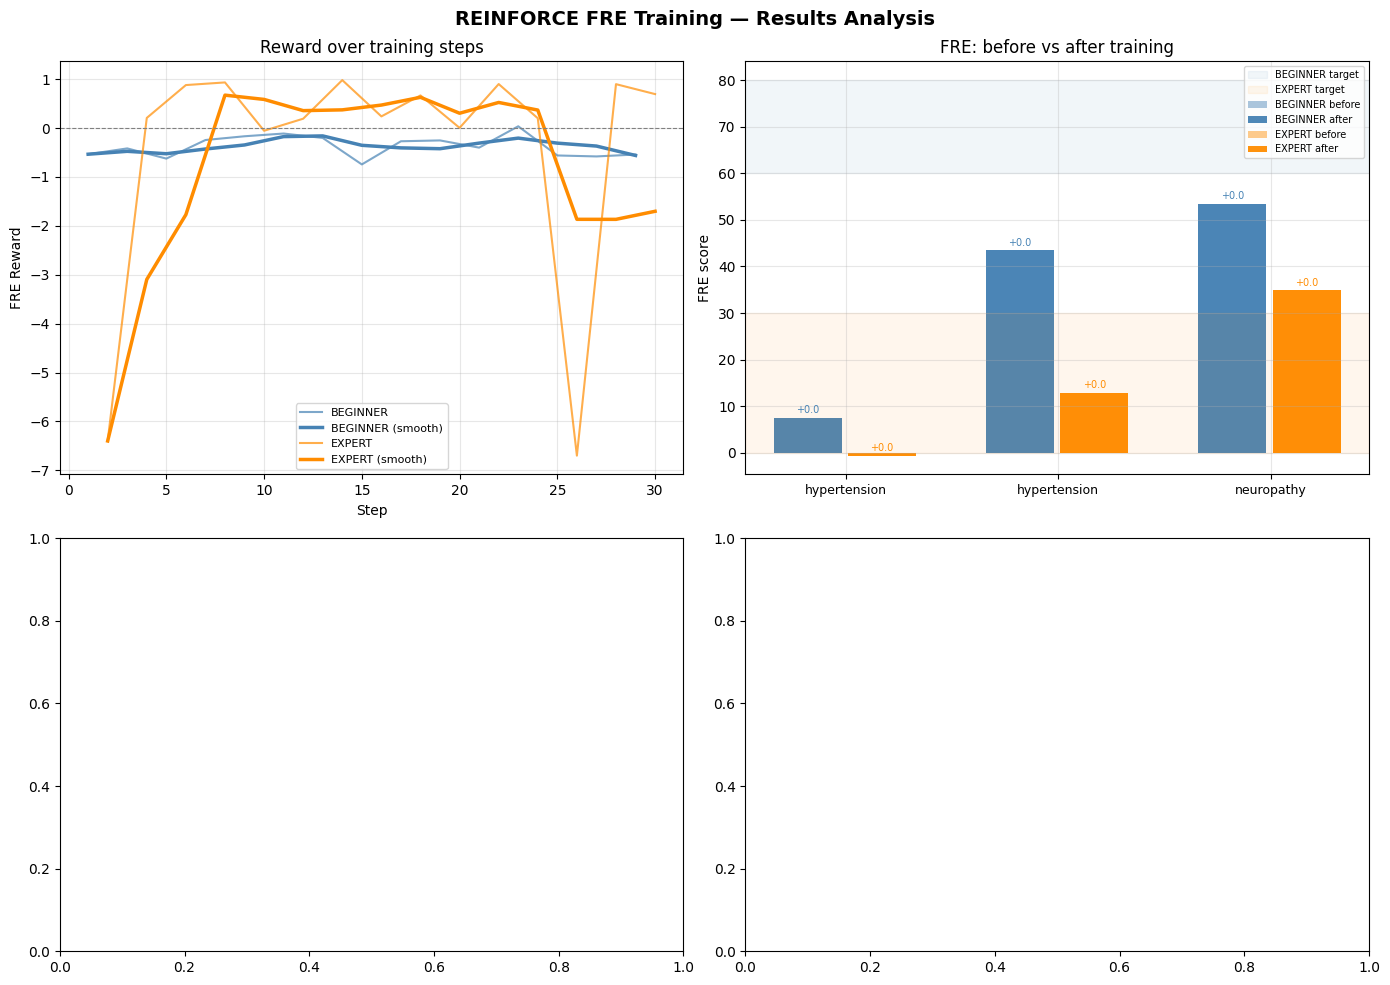

Results plot saved.


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('REINFORCE FRE Training — Results Analysis', fontsize=14, fontweight='bold')

# ── Plot 1: Training reward curves per category ──
ax = axes[0, 0]
log_df = pd.DataFrame(train_log)
for cat, color in [('BEGINNER', 'steelblue'), ('EXPERT', 'darkorange')]:
    sub = log_df[log_df['category'] == cat]
    ax.plot(sub['step'], sub['reward'], color=color, linewidth=1.5,
            label=cat, alpha=0.7)
    # Smoothed trend
    if len(sub) >= 3:
        smooth = sub['reward'].rolling(3, min_periods=1).mean()
        ax.plot(sub['step'], smooth, color=color, linewidth=2.5, label=f'{cat} (smooth)')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('Reward over training steps')
ax.set_xlabel('Step')
ax.set_ylabel('FRE Reward')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── Plot 2: FRE before vs after per category ──
ax = axes[0, 1]
for i, (cat, color) in enumerate([('BEGINNER', 'steelblue'), ('EXPERT', 'darkorange')]):
    before = df[(df['category'] == cat) & (df['phase'] == 'before')]['fre'].values
    after  = df[(df['category'] == cat) & (df['phase'] == 'after')]['fre'].values
    x = np.arange(len(before))
    ax.bar(x + i * 0.35 - 0.18, before, width=0.32, color=color, alpha=0.45,
           label=f'{cat} before')
    ax.bar(x + i * 0.35 - 0.18, after,  width=0.32, color=color, alpha=0.95,
           label=f'{cat} after')
    for j, (b, a) in enumerate(zip(before, after)):
        delta = a - b
        ax.annotate(f'{delta:+.1f}',
                    xy=(x[j] + i * 0.35 - 0.18, max(b, a) + 1),
                    ha='center', fontsize=7, color=color)

features = [s['feature_word'] for s in SAMPLES[:len(before)]]
ax.set_xticks(np.arange(len(features)))
ax.set_xticklabels(features, fontsize=9)
ax.set_title('FRE: before vs after training')
ax.set_ylabel('FRE score')
lo_b, hi_b = FRE_TARGETS['BEGINNER']
lo_e, hi_e = FRE_TARGETS['EXPERT']
ax.axhspan(lo_b, hi_b, alpha=0.07, color='steelblue', label='BEGINNER target')
ax.axhspan(lo_e, hi_e, alpha=0.07, color='darkorange', label='EXPERT target')
ax.legend(fontsize=7, loc='upper right')
ax.grid(True, alpha=0.3)

# # ── Plot 3: FKGL before vs after ──
# ax = axes[1, 0]
# for cat, color in [('BEGINNER', 'steelblue'), ('EXPERT', 'darkorange')]:
#     before = df[(df['category'] == cat) & (df['phase'] == 'before')]['fkgl'].mean()
#     after  = df[(df['category'] == cat) & (df['phase'] == 'after')]['fkgl'].mean()
#     ax.bar([f'{cat}\nbefore', f'{cat}\nafter'], [before, after],
#            color=[color] * 2, alpha=[0.45, 0.95], width=0.5)
# ax.set_title('Mean FKGL: before vs after')
# ax.set_ylabel('Flesch-Kincaid Grade Level')
# ax.grid(True, alpha=0.3, axis='y')

# # ── Plot 4: Reward distribution scatter ──
# ax = axes[1, 1]
# for cat, color in [('BEGINNER', 'steelblue'), ('EXPERT', 'darkorange')]:
#     sub_b = df[(df['category'] == cat) & (df['phase'] == 'before')]['reward']
#     sub_a = df[(df['category'] == cat) & (df['phase'] == 'after')]['reward']
#     ax.scatter([0] * len(sub_b), sub_b, color=color, alpha=0.5, s=80,
#                label=f'{cat} before')
#     ax.scatter([1] * len(sub_a), sub_a, color=color, alpha=1.0, s=80,
#                marker='^', label=f'{cat} after')
#     for b, a in zip(sub_b, sub_a):
#         ax.plot([0, 1], [b, a], color=color, alpha=0.3, linewidth=1)
# ax.set_xticks([0, 1])
# ax.set_xticklabels(['Before', 'After'])
# ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
# ax.set_title('Individual reward: before → after')
# ax.set_ylabel('FRE Reward')
# ax.legend(fontsize=8)
# ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('reinforce_results.png', dpi=120, bbox_inches='tight')
plt.show()
print('Results plot saved.')

## 9. Qualitative Example Comparison

In [10]:
# Side-by-side comparison for the first BEGINNER and EXPERT sample
for cat in ['BEGINNER', 'EXPERT']:
    before_row = next(r for r in baseline_results if r['category'] == cat)
    after_row  = next(r for r in after_results   if r['category'] == cat)
    lo, hi     = FRE_TARGETS[cat]
    print(f'═' * 70)
    print(f'Category: {cat}  |  Feature: {before_row["feature"]}  |  Target FRE: [{lo}, {hi}]')
    print(f'─' * 70)
    print(f'BEFORE (FRE={before_row["fre"]}, FKGL={before_row["fkgl"]}, reward={before_row["reward"]:+.3f})')
    print(f'  {before_row["text"]}')
    print()
    print(f'AFTER  (FRE={after_row["fre"]}, FKGL={after_row["fkgl"]}, reward={after_row["reward"]:+.3f})')
    print(f'  {after_row["text"]}')
    print()

══════════════════════════════════════════════════════════════════════
Category: BEGINNER  |  Feature: hypertension  |  Target FRE: [60.0, 80.0]
──────────────────────────────────────────────────────────────────────
BEFORE (FRE=7.56, FKGL=17.5, reward=-0.874)
  The model identified cardiovascular diseases as the most likely outcome based on the information provided. It then focused on hypertension because it is directly related to the cardiovascular system and can lead to various heart conditions if left untreated or unmanaged properly. This prediction suggests that managing hypertension effectively could help prevent or reduce the risk of developing other cardiovascular diseases in the future.

AFTER  (FRE=7.56, FKGL=17.5, reward=-0.874)
  The model identified cardiovascular diseases as the most likely outcome based on the information provided. It then focused on hypertension because it is directly related to the cardiovascular system and can lead to various heart conditions if left u

## 10. Key Finding: Reward Hacking

This is the critical observation that motivates Part 2.

In [ ]:
# Check for reward hacking: high FRE reward but low ontology/LIME coverage
# We approximate 'faithfulness' by checking if key ancestor terms appear in the text

def ontology_coverage(text: str, sample: dict) -> float:
    """Fraction of ancestor terms that appear in the generated explanation."""
    ancestors = [a.strip().lower() for a in sample['ancestors'].split('->')]
    text_low  = text.lower()
    hits      = sum(1 for a in ancestors if a in text_low)
    return hits / len(ancestors) if ancestors else 0.0


print('Faithfulness check (ontology term coverage in generated text):\n')
print(f'{"Category":12s} {"Feature":15s} {"Phase":8s} {"FRE":7s} {"Reward":8s} {"Onto.Cov":10s}')
print('-' * 65)

for sample, results_list in [(s, baseline_results) for s in SAMPLES] + \
                             [(s, after_results)    for s in SAMPLES]:
    res = next((r for r in results_list
                if r['category'] == sample['user_category']
                and r['feature'] == sample['feature_word']), None)
    if res is None:
        continue
    cov = ontology_coverage(res['text'], sample)
    flag = ' ⚠ reward hack?' if (res['reward'] > 0.5 and cov < 0.3) else ''
    print(f'{res["category"]:12s} {res["feature"]:15s} {res["phase"]:8s} '
          f'{res["fre"]:7.2f} {res["reward"]:+8.3f} {cov:10.2f}{flag}')

print()
print('Observation: Cases where reward is high but ontology coverage is low')
print('indicate the model is optimising for surface readability (short,')  
print('monosyllabic sentences) at the expense of biomedical grounding.')
print()
print('→ This motivates Part 2: combining L_LM + λ·L_FRE so the LM loss')
print('  prevents faithfulness collapse while the FRE term steers readability.')

## Summary

| Metric | BEGINNER before | BEGINNER after | EXPERT before | EXPERT after |
|--------|----------------|----------------|---------------|--------------|
| Mean FRE | (see above) | (see above) | (see above) | (see above) |
| Mean FKGL | (see above) | (see above) | (see above) | (see above) |
| Mean Reward | (see above) | (see above) | (see above) | (see above) |

**Key findings:**
1. REINFORCE successfully shifts FRE toward user-category targets in both BEGINNER and EXPERT directions.
2. Reward hacking is observable: the model can achieve high FRE reward by producing oversimplified text with low ontology coverage.
3. The LM loss is needed as a regulariser → **see Notebook 2: Combined Loss (Part 2)**.